## Imports

In [1]:
import sys
import os
import torch
import torch.utils.data as data
import torch.nn as nn

import neuro_fuzzy_toolbox as nft

## Data

In [2]:
x_train = 2 * torch.rand(200, 2) - 1
x_train

tensor([[-0.0737,  0.0577],
        [ 0.9400,  0.2808],
        [-0.3964, -0.4694],
        [-0.4325, -0.3907],
        [-0.9089, -0.2646],
        [-0.9492,  0.2120],
        [ 0.0322,  0.7112],
        [-0.2864, -0.4332],
        [ 0.3261,  0.2935],
        [ 0.3501,  0.9171],
        [-0.4054,  0.9754],
        [-0.5835,  0.3408],
        [-0.5850,  0.4148],
        [-0.1336,  0.0027],
        [ 0.4097,  0.1397],
        [ 0.5510,  0.3327],
        [ 0.9463,  0.2815],
        [-0.7978,  0.0180],
        [-0.4766,  0.8272],
        [-0.1190, -0.6475],
        [-0.9748, -0.1047],
        [ 0.4220,  0.9457],
        [-0.4788,  0.8965],
        [ 0.3499, -0.0730],
        [-0.7747,  0.0129],
        [ 0.7522, -0.2726],
        [-0.3767,  0.4563],
        [ 0.0120,  0.8469],
        [-0.6504, -0.5171],
        [ 0.7191,  0.4367],
        [ 0.3727,  0.7876],
        [-0.4817,  0.3041],
        [ 0.0445,  0.7667],
        [-0.3976,  0.7829],
        [-0.1859,  0.7648],
        [-0.1588,  0

In [3]:
y_train = torch.rand(200)
y_train

tensor([2.6607e-01, 5.5748e-04, 4.0745e-01, 4.4150e-01, 9.2264e-01, 8.8775e-01,
        8.0606e-01, 6.7393e-01, 2.8831e-01, 6.3259e-02, 5.7095e-01, 4.0310e-01,
        4.3345e-01, 7.0608e-01, 7.2776e-01, 5.2590e-01, 6.4207e-01, 1.8163e-01,
        4.7006e-01, 5.2143e-01, 3.3597e-01, 1.7928e-01, 2.6899e-01, 2.0230e-01,
        3.5275e-01, 3.8158e-01, 1.1512e-01, 3.7944e-01, 6.5333e-01, 9.7616e-01,
        8.2954e-02, 6.6396e-01, 2.4722e-01, 1.1945e-01, 4.4061e-01, 5.8040e-01,
        9.8414e-01, 6.5072e-01, 3.1975e-02, 5.4089e-01, 4.4816e-01, 7.8478e-01,
        4.0588e-01, 4.2403e-01, 2.1625e-01, 4.4363e-01, 3.7767e-01, 6.2453e-01,
        8.0503e-01, 5.3976e-01, 8.3317e-01, 3.0026e-01, 8.7544e-01, 4.0843e-01,
        9.1454e-01, 1.5524e-01, 2.3005e-01, 5.5269e-01, 3.0168e-01, 4.1873e-02,
        9.0155e-01, 9.7856e-01, 8.8212e-01, 2.5430e-01, 2.6573e-01, 4.4683e-01,
        8.9663e-01, 7.6671e-01, 4.0468e-01, 8.7420e-01, 8.0565e-01, 8.8055e-01,
        6.4108e-01, 4.3962e-02, 1.0320e-

## Model

In [4]:
mf_distribution = [3, 2]

In [5]:
model = nft.ANFIS(
    mf_distribution=mf_distribution, # Distribución de las funciones de membresía a lo largo de los features
)

In [6]:
prems = [
    torch.tensor([
        [ 0.8888,  1.4778, -0.9828],
        [ 0.6794,  1.9851,  1.3402],
        [ 0.3820,  1.2675,  0.1291]]), 
    torch.tensor([
        [ 0.2936,  1.4291, -0.4110],
        [ 0.7602,  1.9827,  0.5622]])
    ]

In [7]:
model.set_premises(prems)

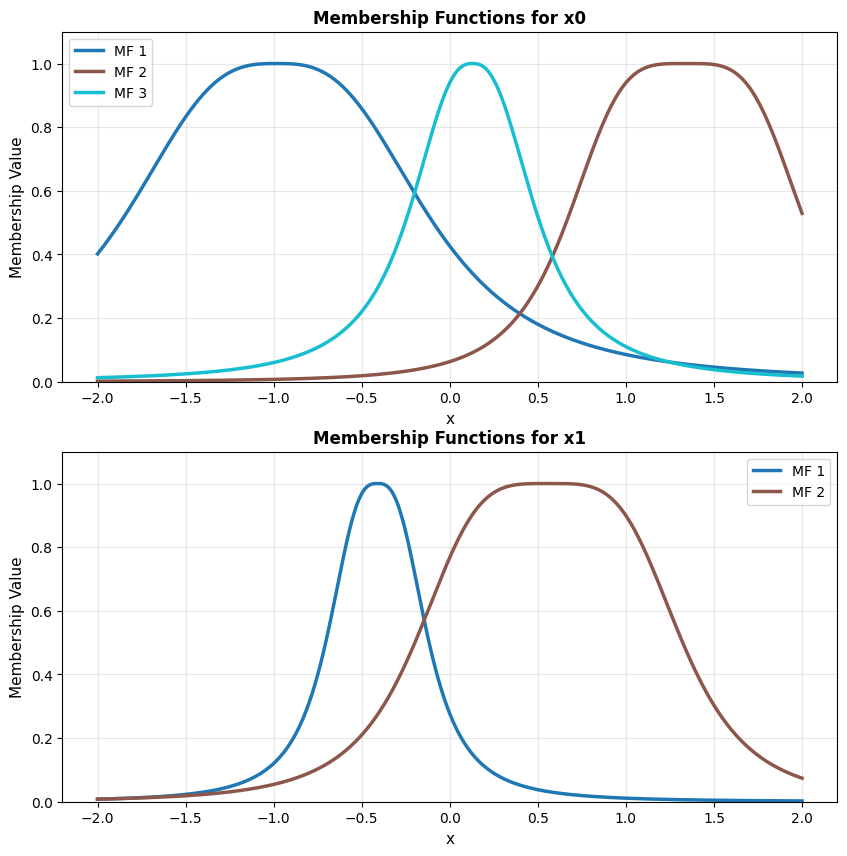

In [8]:
model.plot_premises(group_by_dim=True)

In [9]:
model.get_premises_structure()

x0                      x1                
           a       b       c       a       b       c
MF 1  0.8888  1.4778 -0.9828  0.2936  1.4291 -0.4110
MF 2  0.6794  1.9851  1.3402  0.7602  1.9827  0.5622
MF 3  0.3820  1.2675  0.1291     NaN     NaN     NaN

In [10]:
model.get_premises()

[tensor([[ 0.8888,  1.4778, -0.9828],
         [ 0.6794,  1.9851,  1.3402],
         [ 0.3820,  1.2675,  0.1291]]),
 tensor([[ 0.2936,  1.4291, -0.4110],
         [ 0.7602,  1.9827,  0.5622]])]

## Binary output

In [11]:
x_train = 2 * torch.rand(200, 2) - 1

In [12]:
x_train[:10]

tensor([[-0.3539, -0.6060],
        [-0.2079, -0.2061],
        [-0.3904, -0.7666],
        [ 0.8742, -0.8539],
        [ 0.6572,  0.7963],
        [ 0.9534,  0.1590],
        [ 0.1543, -0.6342],
        [ 0.3610,  0.7532],
        [-0.2928, -0.0075],
        [-0.9567, -0.4444]])

In [13]:
mf_distribution

[3, 2]

In [14]:
bin_model = nft.ANFIS(
    mf_distribution=mf_distribution, # Distribución de las funciones de membresía a lo largo de los features
    output_type='sigmoid', # Tipo de salida: capa sigmoide
)

In [15]:
bin_model.get_premises()

[tensor([[ 1.0431,  2.8192, -0.9212],
         [ 0.9348,  2.6666, -0.2244],
         [ 0.9337,  2.2756, -0.8424]]),
 tensor([[0.9607, 2.4404, 0.4431],
         [0.3986, 2.3140, 0.5805]])]

In [16]:
bin_model.get_consequents()

tensor([[[-0.7503, -0.9459, -0.5305],
         [ 0.0187,  0.6734,  0.4025],
         [-0.7174,  0.7354,  0.8360],
         [ 0.2063, -0.4871, -0.8810],
         [ 0.3351,  0.0982, -0.5120],
         [-0.4154,  0.3722, -0.9265]]])

In [17]:
bin_model(x_train[:10])

tensor([0.5220, 0.5082, 0.5261, 0.4017, 0.4564, 0.4491, 0.4995, 0.4613, 0.5002,
        0.5564], grad_fn=<SigmoidBackward0>)

In [18]:
bin_model.predict(x_train[:10])

tensor([1, 1, 1, 0, 0, 0, 0, 0, 1, 1])

## Multiclass output

In [19]:
x_train = 2 * torch.rand(200, 2) - 1

In [20]:
mul_class_model = nft.ANFIS(
    mf_distribution=mf_distribution, # Distribución de las funciones de membresía a lo largo de los features
    outputs=3, # 3 clases
    output_type='softmax', # Tipo de salida: capa softmax
)

In [21]:
mul_class_model(x_train[:10])

tensor([[ 0.1433, -0.2154, -0.1913],
        [-0.1925,  0.0397, -0.7568],
        [ 0.0255,  0.0458, -0.1272],
        [-0.0133,  0.1134, -0.0444],
        [-0.3823, -0.5594, -0.5725],
        [ 0.0940,  0.5615,  0.7293],
        [-0.3849, -0.8641, -0.5079],
        [ 0.1143,  0.4632,  0.6147],
        [-0.2609, -0.4373, -0.1926],
        [-1.4591, -0.1905, -0.2235]], grad_fn=<SqueezeBackward1>)

In [22]:
mul_class_model(x_train[:10], return_probs=True)

tensor([[0.4142, 0.2894, 0.2964],
        [0.3533, 0.4457, 0.2010],
        [0.3474, 0.3545, 0.2982],
        [0.3221, 0.3656, 0.3122],
        [0.3753, 0.3144, 0.3103],
        [0.2230, 0.3560, 0.4210],
        [0.3994, 0.2474, 0.3532],
        [0.2459, 0.3485, 0.4056],
        [0.3438, 0.2882, 0.3681],
        [0.1251, 0.4447, 0.4302]], grad_fn=<SoftmaxBackward0>)

In [23]:
mul_class_model.predict(x_train[:10])

tensor([0, 1, 1, 1, 0, 2, 0, 2, 2, 1])